#### Find the optimal depth (number of hidden layers) and width(number of neurons in each hidden layer) for the neural network designed in Question 1 and 2.

##### Plot the mean cross-validation accuracies on the final epoch for at least 8 different combinations of different depth (limit to 1-3 layers) and widths (limit to 64, 128 or 256 neurons) using a scatter plot. You may consider different number of neurons for each hidden layer within an architecture. Continue using 5-fold cross validation on the training dataset.

##### Identify the architecture with the highest validation accuracy among all tested combinations.

##### Explain the possible reasons why it performed better than the other architectures.

##### In general, discuss whether accuracy alone is sufficient when selecting the best model. Plot the train and test accuracies against training epochs for the most optimal architecture using a line plot.

##### [optional + 2 marks] Implement an alternative approach that searches through these combinations that could significantly reduce the computational time but achieve similar search results, without enumeration all the possibilities.




This might take a while to run, so plan your time carefully.

1.Firstly, we import relevant libraries.

In [6]:
import tqdm
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

## Configuration for Google Colab
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/SC4001 Neural Network')

from common_utils import set_seed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2.To reduce repeated code, place your

- network (MLP defined in QA1)
- torch datasets (CustomDataset defined in QA1)
- loss function (loss_fn defined in QA1)

in a separate file called **common_utils.py**

Import them into this file. You will not be repenalised for any error in QA1 here as the code in QA1 will not be remarked.

The following code cell will not be marked.

In [7]:
# YOUR CODE HERE
from common_utils import EarlyStopper, loss_fn, MLP, CustomDataset, split_dataset, preprocess_dataset, train_loop, test_loop

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

no_features = 77
no_labels = 1
dropout_rate = 0.3

batch_size = 64
weight_decay = 0.0005
max_epochs = 200
patience = 5

no_folds = 5

seed = 42

# setting seed
set_seed(seed)

3.Perform hyperparameter tuning for different number of  hidden layers and neurons with 5-fold cross validation.

In [8]:
def train(model, X_train_scaled, y_train2, X_val_scaled, y_val2, learning_rate):
    # YOUR CODE HERE
    train_dataset = CustomDataset(X_train_scaled, y_train2)
    val_dataset = CustomDataset(X_val_scaled, y_val2)

    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
    val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)

    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate, weight_decay = weight_decay)
    early_stopper = EarlyStopper(patience = patience, min_delta = 0)

    train_accuracies = []
    train_losses = []
    test_accuracies = []
    test_losses = []
    times = []

    for epoch in range(max_epochs):
        train_loss, train_acc = train_loop(train_loader, model, loss_fn, optimizer)
        val_loss, val_acc = test_loop(val_loader, model, loss_fn)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        test_losses.append(val_loss)
        test_accuracies.append(val_acc)

        times.append(epoch + 1)

        if early_stopper.early_stop(val_loss):
            break

    return train_accuracies, train_losses, test_accuracies, test_losses, times

In [9]:
def find_optimal_hyperparameter(X_train, y_train, parameters, mode, learning_rate):
    # YOUR CODE HERE
    cross_validation_accuracies = []
    cross_validation_times = []

    kf = KFold(n_splits = no_folds, shuffle = True, random_state = seed)

    for no_hidden in parameters:
        print(f"Current {mode}: {len(no_hidden)} hidden layers - {no_hidden} neurons correspondingly")

        fold_accuracies = []
        fold_epochs = []
        fold_number = 1

        for train_idx, val_idx in kf.split(X_train):
            X_tr = X_train[train_idx]
            X_val = X_train[val_idx]
            y_tr = y_train[train_idx]
            y_val = y_train[val_idx]

            X_tr_scaled, X_val_scaled = preprocess_dataset(X_tr, X_val)

            set_seed(seed)
            model = MLP(no_features, no_hidden, no_labels, dropout_rate).to(device)

            train_acc, train_loss, val_acc, val_loss, times = train(model, X_tr_scaled, y_tr, X_val_scaled, y_val, learning_rate)

            fold_accuracies.append(val_acc[-1])
            fold_epochs.append(times[-1])

            print(f"Fold {fold_number}: Accuracy = {val_acc[-1]:.4f}, Epochs = {times[-1]}")
            fold_number += 1

        cross_validation_accuracies.append(np.mean(fold_accuracies))
        cross_validation_times.append(np.mean(fold_epochs))

        print(f"Mean Accuracy: {cross_validation_accuracies[-1]:.4f}, Mean Epochs: {cross_validation_times[-1]:.2f}\n")

    return cross_validation_accuracies, cross_validation_times

In [10]:
'''
optimal_lr = 0. Fill your optimal learning rate in the following code.
'''

# YOUR CODE HERE
optimal_lr = 0.001

no_neurons = [64, 128, 256]
one_layer_parameters = [[n1] for n1 in no_neurons]
two_layer_parameters = [[n1, n2] for n1 in no_neurons for n2 in no_neurons]
three_layer_parameters = [[n1, n2, n3] for n1 in no_neurons for n2 in no_neurons for n3 in no_neurons]
parameters = one_layer_parameters + two_layer_parameters + three_layer_parameters

df = pd.read_csv('/content/drive/MyDrive/SC4001 Neural Network/simplified.csv')
df['label'] = df['filename'].str.split('_').str[-2]

X_train, y_train, X_test, y_test = split_dataset(
    df,
    columns_to_drop = ['filename','label'],
    test_size = 0.25,
    random_state = seed
)

cross_validation_accuracies, cross_validation_times = find_optimal_hyperparameter(X_train.to_numpy(), y_train, parameters, 'Architecture', optimal_lr)

Current Architecture: 1 hidden layers - [64] neurons correspondingly
Fold 1: Accuracy = 0.6567, Epochs = 31
Fold 2: Accuracy = 0.6335, Epochs = 23
Fold 3: Accuracy = 0.6466, Epochs = 29
Fold 4: Accuracy = 0.6742, Epochs = 35
Fold 5: Accuracy = 0.6576, Epochs = 30
Mean Accuracy: 0.6537, Mean Epochs: 29.60

Current Architecture: 1 hidden layers - [128] neurons correspondingly
Fold 1: Accuracy = 0.6805, Epochs = 41
Fold 2: Accuracy = 0.6551, Epochs = 23
Fold 3: Accuracy = 0.6538, Epochs = 21
Fold 4: Accuracy = 0.6886, Epochs = 40
Fold 5: Accuracy = 0.6814, Epochs = 35
Mean Accuracy: 0.6719, Mean Epochs: 32.00

Current Architecture: 1 hidden layers - [256] neurons correspondingly
Fold 1: Accuracy = 0.6523, Epochs = 21
Fold 2: Accuracy = 0.6716, Epochs = 31
Fold 3: Accuracy = 0.6604, Epochs = 25
Fold 4: Accuracy = 0.6753, Epochs = 21
Fold 5: Accuracy = 0.6892, Epochs = 28
Mean Accuracy: 0.6698, Mean Epochs: 25.20

Current Architecture: 2 hidden layers - [64, 64] neurons correspondingly
Fold

4. Plot the mean cross-validation accuracies on the final epoch for at least 8 different combinations of different depth (limit to 1-3 layers) and widths (limit to 64, 128 or 256 neurons) using a scatter plot.

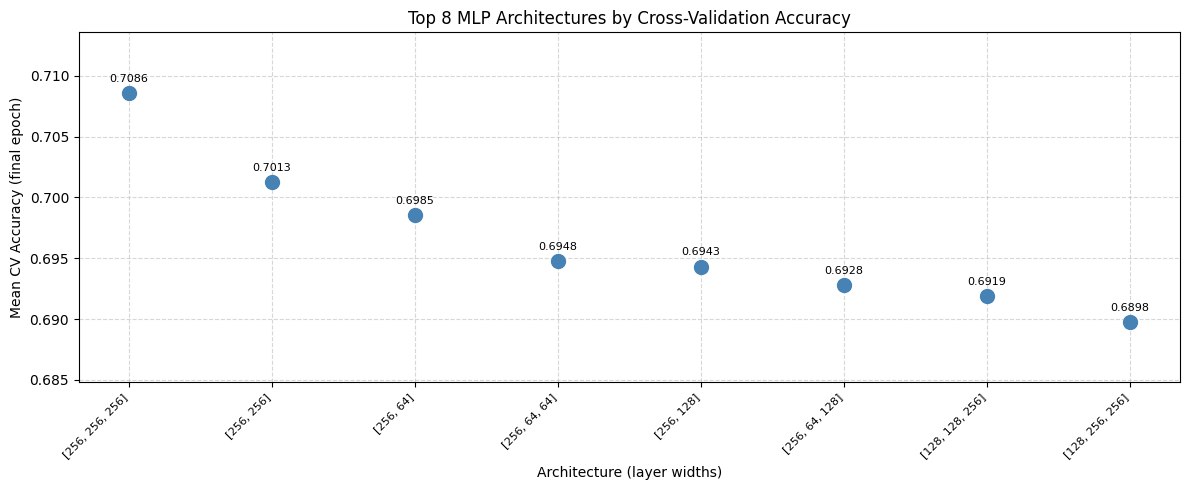

In [11]:
# YOUR CODE HERE
top_8_indices = np.argsort(cross_validation_accuracies)[-8:][::-1]
selected_params = [parameters[i] for i in top_8_indices]
selected_accs = [cross_validation_accuracies[i] for i in top_8_indices]
labels = [str(p) for p in selected_params]

# Dynamic y-axis based on actual data range
y_min = min(selected_accs) - 0.005
y_max = max(selected_accs) + 0.005

plt.figure(figsize=(12, 5))
plt.scatter(range(len(selected_accs)), selected_accs, s = 100, color = 'steelblue', zorder = 3)

for i, (label, acc) in enumerate(zip(labels, selected_accs)):
    plt.annotate(f"{acc:.4f}", (i, acc), textcoords = "offset points", xytext = (0, 8), ha = 'center', fontsize = 8)

plt.xticks(range(len(selected_accs)), labels, rotation = 45, ha = 'right', fontsize = 8)
plt.xlabel('Architecture (layer widths)')
plt.ylabel('Mean CV Accuracy (final epoch)')
plt.title('Top 8 MLP Architectures by Cross-Validation Accuracy')
plt.ylim(y_min, y_max)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

5. Select the optimal combination for the depth and width. State the rationale for your selection.

During the brute force method, the models were evaluated using k-fold cross-validation on the training set only, the test set was never seen. The accuracy reported is the cross-validation accuracy, which is an estimate of how well each architecture generalises, not the actual true final performance. Which is why we should take the top 8 model selected and train them and verify with test set to get the model with the highest accuracy as the most optimal model.

In [13]:
results = {}

for combo in selected_params:
    print(f"Training {combo}...")
    set_seed(seed)
    m = MLP(no_features, combo, no_labels, dropout_rate).to(device)
    X_train_scaled, X_test_scaled = preprocess_dataset(X_train.to_numpy(), X_test.to_numpy())
    tr_acc, tr_loss, v_acc, v_loss, eps = train(m, X_train_scaled, y_train, X_test_scaled, y_test, optimal_lr)
    results[str(combo)] = {
        'train_acc': tr_acc,
        'val_acc': v_acc,
        'epochs': eps,
        'final_val_acc': v_acc[-1],
        'model': m
    }
    print(f"Final Test Accuracy: {v_acc[-1]:.6f}\n")

# Find and save the most optimal model
best_combo = max(results, key=lambda x: results[x]['final_val_acc'])
optimal_model = results[best_combo]['model']

print(f"Best Architecture: {best_combo}")
print(f"Best Test Accuracy: {results[best_combo]['final_val_acc']:.6f}")

Training [256, 256, 256]...
Final Test Accuracy: 0.725705

Training [256, 256]...
Final Test Accuracy: 0.742952

Training [256, 64]...
Final Test Accuracy: 0.701161

Training [256, 64, 64]...
Final Test Accuracy: 0.720398

Training [256, 128]...
Final Test Accuracy: 0.722056

Training [256, 64, 128]...
Final Test Accuracy: 0.714760

Training [128, 128, 256]...
Final Test Accuracy: 0.695522

Training [128, 256, 256]...
Final Test Accuracy: 0.694527

Best Architecture: [256, 256]
Best Test Accuracy: 0.742952


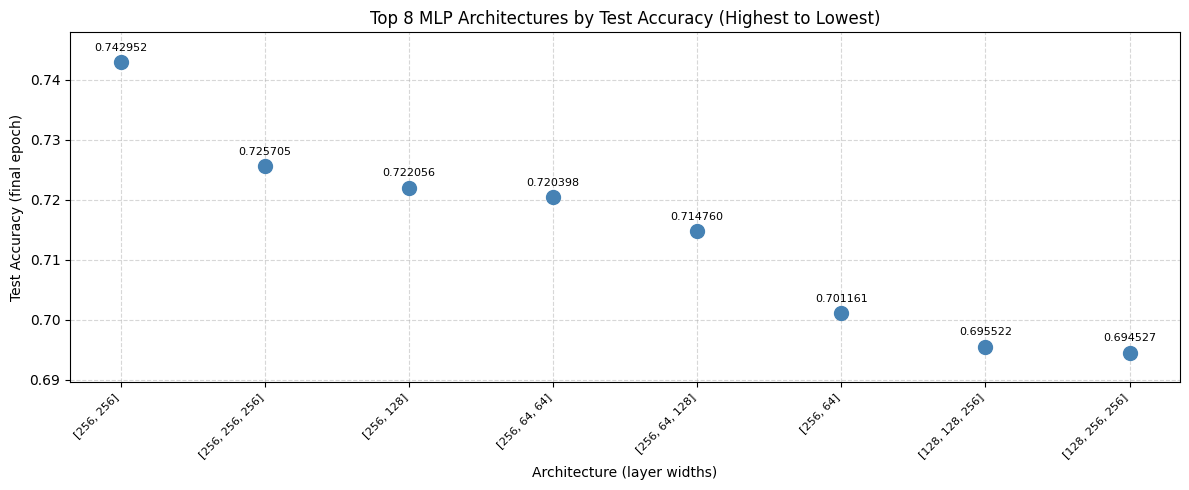

In [14]:
sorted_results = sorted(results.items(), key = lambda x: x[1]['final_val_acc'], reverse = True)
labels = [r[0] for r in sorted_results]
final_accs = [r[1]['final_val_acc'] for r in sorted_results]

y_min = min(final_accs) - 0.005
y_max = max(final_accs) + 0.005

plt.figure(figsize = (12, 5))
plt.scatter(range(len(final_accs)), final_accs, s = 100, color = 'steelblue', zorder = 3)

for i, (label, acc) in enumerate(zip(labels, final_accs)):
    plt.annotate(f"{acc:.6f}", (i, acc), textcoords = "offset points", xytext = (0, 8), ha = 'center', fontsize = 8)

plt.xticks(range(len(final_accs)), labels, rotation = 45, ha = 'right', fontsize = 8)
plt.xlabel('Architecture (layer widths)')
plt.ylabel('Test Accuracy (final epoch)')
plt.title('Top 8 MLP Architectures by Test Accuracy (Highest to Lowest)')
plt.ylim(y_min, y_max)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

In [17]:
optimal_combination = eval(best_combo) # Do this because best_combo was converted to string when stored in a dict
reason = f"""
The {optimal_combination} architecture achieved the highest test accuracy of {results[best_combo]['final_val_acc']:.6f}.
During k-fold cross-validation, [256, 256, 256] ranked first because its larger capacity helped it fit the training folds better on average. However,
when trained on the full training set and evaluated with test set, {optimal_combination} outperformed it, suggesting that [256, 256, 256] was slightly
overfitting, performing well on training folds but couldn't generalise as well to unseen data. We should trust the test accuracy more and choose
{optimal_combination} as the optimal model because the test set is data the model has never seen in any form, giving a truly unbiased measure of
real-world performance. Furthermore, {optimal_combination} being a simpler architecture with fewer parameters means it is less prone to overfitting,
making it a more reliable choice.
"""

# YOUR CODE HERE
print(f"The Optimal Architecture: {optimal_combination}")
print(f"The Reason: {reason}")

The Optimal Architecture: [256, 256]
The Reason: 
The [256, 256] architecture achieved the highest test accuracy of 0.742952. 
During k-fold cross-validation, [256, 256, 256] ranked first because its larger capacity helped it fit the training folds better on average. However, 
when trained on the full training set and evaluated with test set, [256, 256] outperformed it, suggesting that [256, 256, 256] was slightly 
overfitting, performing well on training folds but couldn't generalise as well to unseen data. We should trust the test accuracy more and choose 
[256, 256] as the optimal model because the test set is data the model has never seen in any form, giving a truly unbiased measure of 
real-world performance. Furthermore, [256, 256] being a simpler architecture with fewer parameters means it is less prone to overfitting, 
making it a more reliable choice.



6.Plot the train and test accuracies against training epochs for the most optimal architecture using a line plot.


Final Train Accuracy: 0.853462
Final Train Loss: 0.331159
Final Test Accuracy: 0.742952
Final Test Loss: 0.559487
Total Training Epochs: 37


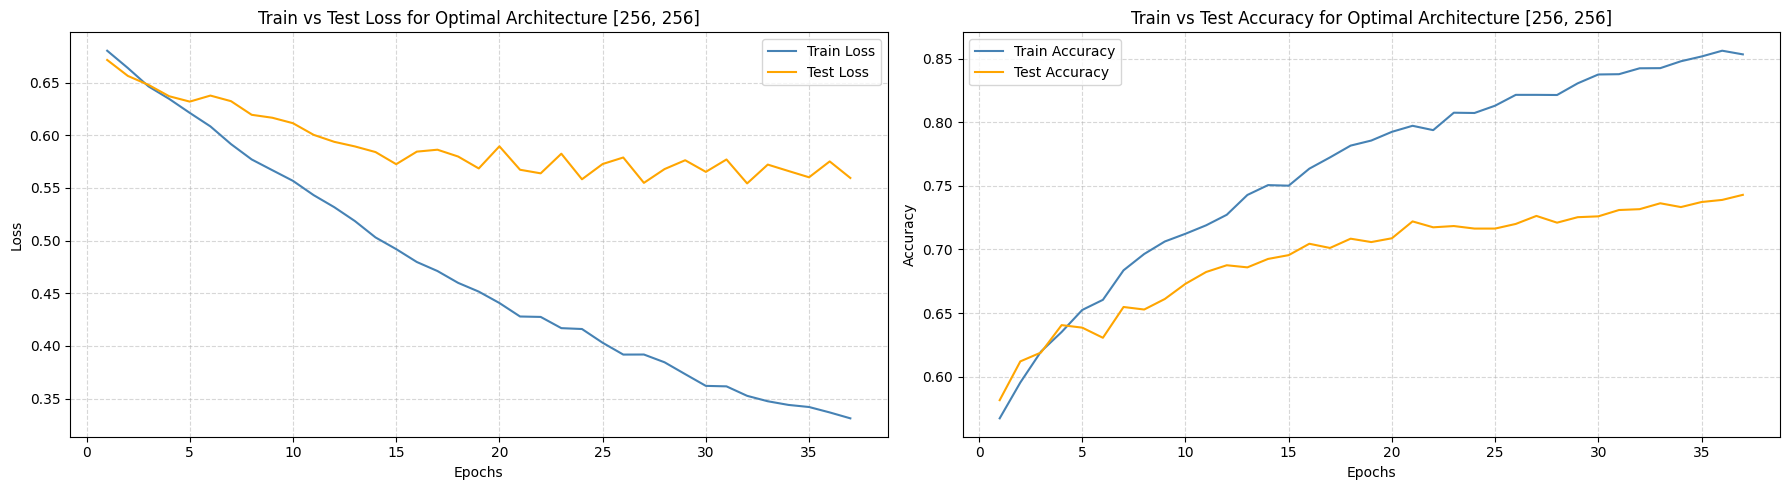

In [18]:
# YOUR CODE HERE
X_train_scaled, X_test_scaled = preprocess_dataset(X_train, X_test)
set_seed(seed)
optimal_model = MLP(no_features, optimal_combination, no_labels, dropout_rate).to(device)
train_acc, train_loss, test_acc, test_loss, epochs = train(optimal_model, X_train_scaled, y_train, X_test_scaled, y_test, optimal_lr)
print(f"Final Train Accuracy: {train_acc[-1]:.6f}")
print(f"Final Train Loss: {train_loss[-1]:.6f}")
print(f"Final Test Accuracy: {test_acc[-1]:.6f}")
print(f"Final Test Loss: {test_loss[-1]:.6f}")
print(f"Total Training Epochs: {epochs[-1]}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Loss plot (left)
axes[0].plot(epochs, train_loss, label = 'Train Loss', color = 'steelblue')
axes[0].plot(epochs, test_loss, label = 'Test Loss', color = 'orange')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'Train vs Test Loss for Optimal Architecture {optimal_combination}')
axes[0].legend()
axes[0].grid(True, linestyle = '--', alpha = 0.5)

# Accuracy plot (right)
axes[1].plot(epochs, train_acc, label = 'Train Accuracy', color = 'steelblue')
axes[1].plot(epochs, test_acc, label = 'Test Accuracy', color = 'orange')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'Train vs Test Accuracy for Optimal Architecture {optimal_combination}')
axes[1].legend()
axes[1].grid(True, linestyle = '--', alpha = 0.5)

plt.tight_layout()
plt.show()

7.As you've astutely observed, we're facing a significant challenge in enumerating all possible combinations of widths and depths and searching over them. Given the circumstances, could you explore and implement a more efficient method for searching through these combinations that could significantly reduce the computational time but achieve similar search results?

In [19]:
# YOUR CODE HERE
def train_with_epochs(model, X_train_scaled, y_train, X_val_scaled, y_val, learning_rate, max_epochs):
    train_dataset = CustomDataset(X_train_scaled, y_train)
    val_dataset = CustomDataset(X_val_scaled, y_val)

    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
    val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)

    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate, weight_decay = weight_decay)
    early_stopper = EarlyStopper(patience = patience, min_delta = 0)

    train_accuracies = []
    train_losses = []
    test_accuracies = []
    test_losses = []
    times = []

    for epoch in range(max_epochs):
        train_loss, train_acc = train_loop(train_loader, model, loss_fn, optimizer)
        val_loss, val_acc = test_loop(val_loader, model, loss_fn)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        test_losses.append(val_loss)
        test_accuracies.append(val_acc)

        times.append(epoch + 1)

        if early_stopper.early_stop(val_loss):
            break

    return train_accuracies, train_losses, test_accuracies, test_losses, times

In [20]:
def successive_halving_search(parameters, X_train, y_train, learning_rate):
    print("Initial architectures:", len(parameters))

    epoch_schedule = [5, 10, 15]
    fold_schedule = [2, 3, 5]

    for round_idx, epochs in enumerate(epoch_schedule):
        print(f"\n===== Round {round_idx + 1} | Epochs = {epochs} =====")

        kf = KFold(n_splits = fold_schedule[round_idx], shuffle = True, random_state = seed)
        scores = []

        for arch in parameters:
            fold_scores = []

            for train_idx, val_idx in kf.split(X_train):
                X_tr = X_train[train_idx]
                X_val = X_train[val_idx]
                y_tr = y_train[train_idx]
                y_val = y_train[val_idx]

                X_tr_scaled, X_val_scaled = preprocess_dataset(X_tr, X_val)

                set_seed(seed)
                model = MLP(no_features, arch, no_labels, dropout_rate).to(device)
                train_acc, train_loss, val_acc, val_loss, times = train_with_epochs(model, X_tr_scaled, y_tr, X_val_scaled, y_val, learning_rate, epochs)

                fold_scores.append(val_acc[-1])

            mean_score = np.mean(fold_scores)
            scores.append((arch, mean_score))
            print(f"Architecture {arch} → Accuracy {mean_score:.4f}")

        scores.sort(key = lambda x: x[1], reverse = True)
        keep = len(scores) // 2
        parameters = [s[0] for s in scores[:keep]]

        print(f"\nKeeping top {keep} architectures")

        for s in scores[:keep]:
            print("Survivor:", s)

    best4_architecture = parameters[:4]
    print("\nBest 4 Architecture Found:", best4_architecture)

    return best4_architecture

In [21]:
top_4_architecture = successive_halving_search(parameters, X_train.to_numpy(), y_train, optimal_lr)

Initial architectures: 39

===== Round 1 | Epochs = 5 =====
Architecture [64] → Accuracy 0.5873
Architecture [128] → Accuracy 0.5907
Architecture [256] → Accuracy 0.6008
Architecture [64, 64] → Accuracy 0.5834
Architecture [64, 128] → Accuracy 0.5814
Architecture [64, 256] → Accuracy 0.5935
Architecture [128, 64] → Accuracy 0.5953
Architecture [128, 128] → Accuracy 0.5849
Architecture [128, 256] → Accuracy 0.6001
Architecture [256, 64] → Accuracy 0.5992
Architecture [256, 128] → Accuracy 0.6057
Architecture [256, 256] → Accuracy 0.6031
Architecture [64, 64, 64] → Accuracy 0.5850
Architecture [64, 64, 128] → Accuracy 0.5865
Architecture [64, 64, 256] → Accuracy 0.5925
Architecture [64, 128, 64] → Accuracy 0.5770
Architecture [64, 128, 128] → Accuracy 0.5853
Architecture [64, 128, 256] → Accuracy 0.5863
Architecture [64, 256, 64] → Accuracy 0.5938
Architecture [64, 256, 128] → Accuracy 0.5931
Architecture [64, 256, 256] → Accuracy 0.5915
Architecture [128, 64, 64] → Accuracy 0.5883
Archi

In [25]:
name_of_method = "Successive Halving (with Early Stopping)"

results_of_method = """
From the best 4 architecture found using this method, the top 2 is the same as the Top 2 from the Top 8 MLP Architectures Graph using the old brute force method. So we
essentially achieved similar results but significantly reduced computational time. In our case, even though the 3rd best & 4th best architecture found from the old method
has been eliminated early on, we still managed to find the 2nd Best and 1st Best as the top 2 through this method.
"""

reason_of_use = """
Successive halving is used to significantly reduce computational time by early-stopping poor-performing architectures. Instead of exhausting resources on every possible
combination, it allocates more training epochs only to the most promising candidates, allowing for a much wider search space to be explored within the same time budget.
In our case, we also further shorten the time by doing less folds for less promising candidates.
"""

drawback = """
The primary drawback is the risk of "aggressive pruning," where a potentially optimal architecture is eliminated just because it starts learning slowly in the first few
epochs. Some complex models require more time to converge and might be outshined by simpler, faster-starting models during the initial stages, leading to a sub-optimal
final selection. In our case, we can see that the 4th Best Model [256, 64, 64] did get eliminated early on due to this reason.
"""

print(f"Method Used: {name_of_method}\n")
print(f"Top 4 Results Achieved (Sorted Descendingly by Scores): {top_4_architecture}\n")
print(f"Results Explanation: {results_of_method}")
print(f"Reason of Method: {reason_of_use}")
print(f"Drawback of Method: {drawback}")

Method Used: Successive Halving (with Early Stopping)

Top 4 Results Achieved (Sorted Descendingly by Scores): [[256, 256], [256, 256, 256], [256, 128, 256], [256, 128, 128]]

Results Explanation: 
From the best 4 architecture found using this method, the top 2 is the same as the Top 2 from the Top 8 MLP Architectures Graph using the old brute force method. So we 
essentially achieved similar results but significantly reduced computational time. In our case, even though the 3rd best & 4th best architecture found from the old method 
has been eliminated early on, we still managed to find the 2nd Best and 1st Best as the top 2 through this method.

Reason of Method: 
Successive halving is used to significantly reduce computational time by early-stopping poor-performing architectures. Instead of exhausting resources on every possible 
combination, it allocates more training epochs only to the most promising candidates, allowing for a much wider search space to be explored within the same 

In [23]:
# Save The Optimal Model for Part A4
torch.save(optimal_model.state_dict(), '/content/drive/MyDrive/SC4001 Neural Network/a3modelBest.pth')